In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import binom
from scipy.integrate import solve_ivp


In [83]:
# network functions
def load_group_statistics(network, path="Data/group_statistics.txt"):
    """
    Load group-size and membership statistics for a given network.

    The function reads a JSON file containing empirical group statistics and
    returns the corresponding membership distribution, group-size distribution,
    and structural metadata required by the wAMEs framework.

    Parameters
    ----------
    network : str
        Name of the network to load.
    path : str, optional
        Path to the JSON file containing the group statistics.

    Returns
    -------
    tuple
        ``(gm, pn, mmax, nmax, state_meta)``, where

        - ``gm`` is the membership distribution,
        - ``pn`` is the group-size distribution,
        - ``mmax`` is the maximum membership,
        - ``nmax`` is the maximum group size,
        - ``state_meta`` is the structural metadata returned by
          ``get_state_meta``.

    Raises
    ------
    FileNotFoundError
        If the statistics file does not exist.
    KeyError
        If the requested network is not found in the file.
    ValueError
        If the loaded distributions are empty or invalid.
    """
    with open(path, "r") as f:
        results = json.load(f)

    if network not in results:
        available = ", ".join(sorted(results.keys()))
        raise KeyError(
            f"Network '{network}' not found in '{path}'. "
            f"Available networks: {available}"
        )

    data = results[network]

    n_vals = data["group_size_n"]
    p_vals = data["group_size_p"]
    k_vals = data["membership_k"]
    g_vals = data["membership_g"]

    if len(n_vals) == 0 or len(k_vals) == 0:
        raise ValueError(f"Network '{network}' has empty group statistics.")

    nmax = int(max(n_vals))
    mmax = int(max(k_vals))

    pn = np.zeros(nmax + 1, dtype=float)
    gm = np.zeros(mmax + 1, dtype=float)

    for n, p in zip(n_vals, p_vals):
        pn[int(n)] = float(p)

    for k, g in zip(k_vals, g_vals):
        gm[int(k)] = float(g)
        
    pmax = float(np.max(pn[2:]))

    state_meta = get_state_meta(mmax, nmax, gm, pn)

    return gm, pn, mmax, nmax, pmax, state_meta

def get_state_meta(mmax, nmax, gm, pn):
    """
    From https://github.com/gstonge/gcm

    Return a tuple containing structural metadata for the system.

    Parameters
    ----------
    mmax : int
        Maximum membership.
    nmax : int
        Maximum group size, with nmax >= 2.
    gm : array_like
        Membership distribution of length mmax + 1.
    pn : array_like
        Group-size distribution of length nmax + 1.

    Returns
    -------
    tuple
        Tuple containing useful arrays that describe the structure.
    """
    m = np.arange(0, mmax + 1)
    imat = np.zeros((nmax + 1, nmax + 1))
    nmat = np.zeros((nmax + 1, nmax + 1))

    for n in range(2, nmax + 1):
        imat[n, 0:n + 1] = np.arange(n + 1)
        nmat[n, 0:n + 1] = np.ones(n + 1) * n

    pnmat = np.outer(pn, np.ones(nmax + 1))
    return (mmax, nmax, m, np.array(gm), np.array(pn), imat, nmat, pnmat)

# kernel
def w_diversity_intolerance(n, i, scale):
    """Nodes flee diverse groups — prefer homogeneous ones (allegiance/homophily).
    Rate peaks at phi=0.5 and is zero at the homogeneous extremes (phi=0 or 1)."""
    phi = i / n
    return scale**2 * phi * (1 - phi)

# integration
def integrate_I_traj_kernel(
    lam,
    w_func,
    state_meta,
    nmax,
    mmax,
    gm,
    mu,
    nu,
    w_args=(),
    I0=1e-5,
    traj_points=200000,
    t_max=None,
):
    """
    Integrate the infected-fraction trajectory using a group-state-dependent
    switching-rate kernel.

    Mirrors ``integrate_I_traj`` but replaces the scalar ``w`` with a
    callable ``w_func(n, i, *w_args)`` that can encode diversity-seeking,
    allegiance-driven, or any other (n, i)-dependent group switching
    behaviour.  Internally the kernel is evaluated once into a precomputed
    matrix and passed to ``vector_field_w_kernel``.

    Parameters
    ----------
    lam : float
        Transmission-rate prefactor.
    w_func : callable
        Switching-rate function ``w_func(n, i, *w_args)``.  Returns the
        rate at which a node in a group of size ``n`` with ``i`` infected
        members switches to a new group.
    state_meta : tuple
        Structural metadata returned by ``get_state_meta``.
    nmax : int
        Maximum group size.
    mmax : int
        Maximum membership.
    gm : ndarray
        Membership distribution.
    mu : float
        Recovery rate.
    nu : float
        Synergy exponent in the infection rate ``beta(n, i) = lam * i**nu``.
    w_args : tuple, optional
        Extra arguments forwarded to ``w_func``.
    I0 : float, optional
        Initial infected fraction.
    traj_points : int, optional
        Number of time points stored along the trajectory.
    t_max : float, optional
        Final integration time.  If ``None``, defaults to ``traj_points``.

    Returns
    -------
    tuple of ndarray
        ``(t, I)``, where ``t`` is the integration time grid and ``I`` is the
        corresponding trajectory of the infected fraction.
    """
    if not (0.0 <= I0 <= 1.0):
        raise ValueError("I0 must be between 0 and 1.")
    if traj_points < 2:
        raise ValueError("traj_points must be at least 2.")

    inf_mat = infection_matrix(
        lambda n, i: lam * i**nu,
        nmax,
    )
    w_mat = switching_matrix(w_func, nmax, args=w_args)

    sm, fni = initialize(state_meta, initial_density=I0)
    v0 = np.concatenate((sm, fni.reshape((nmax + 1) ** 2)))

    if t_max is None:
        t_max = float(traj_points)

    t = np.linspace(0.0, t_max, traj_points)
    t_span = (t[0], t[-1])

    sol = solve_ivp(
        lambda time, state: vector_field_w_kernel(state, time, inf_mat, w_mat, state_meta, mu),
        t_span=t_span,
        y0=v0,
        method="LSODA",
        t_eval=t,
    )

    if not sol.success:
        raise RuntimeError(f"Trajectory integration failed: {sol.message}")

    v_traj = sol.y.T
    I_traj = np.array(
        [infected_fraction(v[:mmax + 1], gm) for v in v_traj],
        dtype=float,
    )
    # return distribution of group states instead of just the infected fraction trajectory
    fni_traj = np.array(
        [v[mmax + 1:].reshape((nmax + 1, nmax + 1)) for v in v_traj],
        dtype=float,
    )

    return t, I_traj, fni_traj

def infection_matrix(beta, nmax, args=()):
    """
    From https://github.com/gstonge/gcm

    Return the infection-rate matrix evaluated at each pair (n, i).

    Parameters
    ----------
    beta : callable
        Infection-rate function of the form beta(n, i, *args).
    nmax : int
        Maximum group size, with nmax >= 2.
    args : tuple, optional
        Additional arguments passed to the infection-rate function.

    Returns
    -------
    ndarray
        Array of shape (nmax + 1, nmax + 1) containing the infection rate
        at each pair (n, i).
    """
    inf_mat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        for i in range(n):
            inf_mat[n, i] = beta(n, i, *args)
    return inf_mat

def switching_matrix(w_func, nmax, args=()):
    """
    Construct the group-switching-rate matrix evaluated at each (n, i) pair.

    Analogous to ``infection_matrix``, but for the group switching rate ω.
    The resulting matrix can be passed to ``vector_field_w_kernel`` in place
    of a scalar ω, allowing the switching rate to depend on group size ``n``
    and the number of infected members ``i``.

    Parameters
    ----------
    w_func : callable
        Switching-rate function of the form ``w_func(n, i, *args)``.
        Returns the rate at which a node in a group of size ``n`` with ``i``
        infected members switches to a new group.
    nmax : int
        Maximum group size.
    args : tuple, optional
        Additional arguments passed to ``w_func``.

    Returns
    -------
    ndarray
        Array of shape ``(nmax + 1, nmax + 1)`` where entry ``[n, i]`` is
        ``w_func(n, i, *args)`` for valid pairs and 0 elsewhere.
    """
    w_mat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        for i in range(n + 1):
            w_mat[n, i] = w_func(n, i, *args)
    return w_mat

def initialize(state_meta, initial_density=0.5):
    """
    Initialize the node and group states from a homogeneous infected fraction.

    From https://github.com/gstonge/gcm

    The initial condition assumes that each node is infected independently
    with probability ``initial_density``. Under this assumption, the
    distribution of infected nodes within groups of size ``n`` is binomial.

    Parameters
    ----------
    state_meta : tuple
        Structural metadata returned by ``get_state_meta``.
    initial_density : float, optional
        Initial fraction of infected nodes.

    Returns
    -------
    tuple of ndarray
        ``(sm, fni)``, where ``sm[m]`` is the probability that a node of
        membership ``m`` is susceptible, and ``fni[n, i]`` is the fraction
        of groups of size ``n`` containing ``i`` infected nodes.
    """
    mmax = state_meta[0]
    nmax = state_meta[1]

    sm = np.full(mmax + 1, 1.0 - initial_density, dtype=float)
    fni = np.zeros((nmax + 1, nmax + 1), dtype=float)

    for n in range(2, nmax + 1):
        infected_counts = np.arange(n + 1, dtype=int)
        fni[n, :n + 1] = binom.pmf(infected_counts, n, initial_density)

    return sm, fni

def vector_field_w_kernel(v, t, inf_mat, w_mat, state_meta, mu):
    """
    Evaluate the dynamical vector field with a group-state-dependent switching
    rate kernel.

    Drop-in replacement for ``vector_field_w`` where the scalar ``w`` is
    replaced by a precomputed matrix ``w_mat[n, i]`` built via
    ``switching_matrix``.  This allows the group switching rate to depend on
    group size ``n`` and the number of infected members ``i``, enabling
    modelling of diversity-seeking or allegiance-driven group dynamics.

    Parameters
    ----------
    v : ndarray
        Flattened state vector containing both node and group states, as
        produced by ``flatten``.
    t : float
        Time variable (unused, included for compatibility with ODE solvers).
    inf_mat : ndarray
        Infection-rate matrix of shape ``(nmax + 1, nmax + 1)``.
    w_mat : ndarray
        Switching-rate matrix of shape ``(nmax + 1, nmax + 1)``, where
        ``w_mat[n, i]`` is the rate at which a node in a group of size ``n``
        with ``i`` infected members switches to a new group.  Build this with
        ``switching_matrix``.
    state_meta : tuple
        Structural metadata returned by ``get_state_meta``.
    mu : float
        Recovery rate.

    Returns
    -------
    ndarray
        Time derivative of the flattened state vector.
    """
    mmax = state_meta[0]
    nmax = state_meta[1]
    m = state_meta[2]
    gm = state_meta[3]
    pn = state_meta[4]
    imat = state_meta[5]
    nmat = state_meta[6]
    pnmat = state_meta[7]

    sm = v[:mmax + 1]
    fni = v[mmax + 1:].reshape((nmax + 1, nmax + 1))

    sm_field = np.zeros(sm.shape)
    fni_field = np.zeros(fni.shape)

    # Mean-field quantities
    r = np.sum(
        inf_mat[2:, :] * (nmat[2:, :] - imat[2:, :]) * fni[2:, :] * pnmat[2:, :]
    )
    r /= np.sum((nmat[2:, :] - imat[2:, :]) * fni[2:, :] * pnmat[2:, :])

    rho = r * excess_susceptible_membership(m, gm, sm)
    I = infected_fraction(sm, gm)

    # need to be more defensive here:
    # if denom is > 0 there are mixed groups contributing to the switching flux,
    # so LHD's weighted formula is valid and gives the correct bias in who gets swapped.
    S_w_denom = np.sum(nmat[2:, :] * w_mat[2:, :] * fni[2:, :] * pnmat[2:, :])
    if S_w_denom > 1e-14:
        S_w = (
            np.sum((nmat[2:, :] - imat[2:, :]) * w_mat[2:, :] * fni[2:, :] * pnmat[2:, :])
            / S_w_denom
        )
    else:
        S_w = 1.0 - I  # fallback to the original mean-field switching term if the kernel is degenerate
    sm_field = mu * (1.0 - sm) - sm * m * r

    # i+1 -> i
    fni_field[2:, :nmax] += (
        imat[2:, 1:]
        * (mu + w_mat[2:, 1:] * S_w)          # was (1 - S_w)
        * fni[2:, 1:]
    )

    # diagonal outflow
    fni_field[2:, :] += (
        -imat[2:, :] * (mu + w_mat[2:, :] * S_w)          # was (1 - S_w)
        - (nmat[2:, :] - imat[2:, :]) * (inf_mat[2:, :] + rho + w_mat[2:, :] * (1.0 - S_w))  # was S_w
    ) * fni[2:, :]

    # i-1 -> i
    fni_field[2:, 1:nmax + 1] += (
        (nmat[2:, :nmax] - imat[2:, :nmax])
        * (inf_mat[2:, :nmax] + rho + w_mat[2:, :nmax] * (1.0 - S_w))  # was S_w
        * fni[2:, :nmax]
    )
    return np.concatenate((sm_field, fni_field.reshape((nmax + 1) ** 2)))

def excess_susceptible_membership(m, gm, sm):
    """
    From https://github.com/gstonge/gcm

    Compute the excess membership of a susceptible node reached by following
    a random group-edge.

    Parameters
    ----------
    m : ndarray
        Membership values.
    gm : ndarray
        Membership distribution.
    sm : ndarray
        Probability that a node of membership m is susceptible.

    Returns
    -------
    float
        Excess membership of susceptible nodes.
    """
    return np.sum(m * (m - 1) * sm * gm) / np.sum(m * sm * gm)

def infected_fraction(sm, gm):
    """
    From https://github.com/gstonge/gcm

    Compute the total fraction of infected nodes.

    Parameters
    ----------
    sm : ndarray
        Probability that a node of membership m is susceptible.
    gm : ndarray
        Membership distribution.

    Returns
    -------
    float
        Fraction of infected nodes.
    """
    return np.sum((1.0 - sm) * gm)

In [84]:
# Load group statistics
network = "CNS"
gm, pn, mmax, nmax, pmax, state_meta = load_group_statistics(
    network,
    path="Data/group_statistics.txt",
)

nu = 9.5
mu = 1.0
w = 5.0
lam_kernel = 2e-3
scale = w           

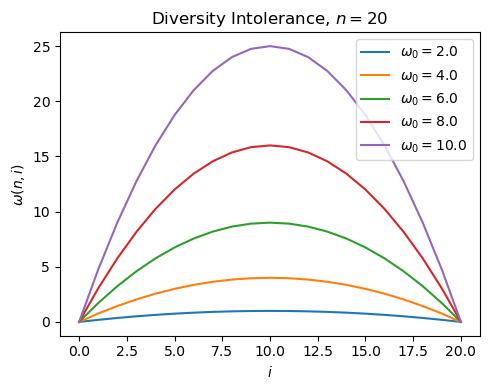

In [85]:
n = nmax  # e.g. nmax for Thiers13
i_vals = np.arange(0, n+1)
scales = [2.0, 4.0, 6.0, 8.0, 10.0]

fig, ax = plt.subplots(figsize=(5, 4))

for scale in scales:
    w_vals = [w_diversity_intolerance(n, i, scale) for i in i_vals]
    ax.plot(i_vals, w_vals, label=rf"$\omega_0={scale}$")

ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$\omega(n,i)$")
ax.set_title(rf"Diversity Intolerance, $n={n}$")
ax.legend()
plt.tight_layout()
plt.savefig("./figures/allegiance_kernel.png", dpi=300)
plt.show()

Running trajectory integration with allegiance kernel (scale=7.0)...


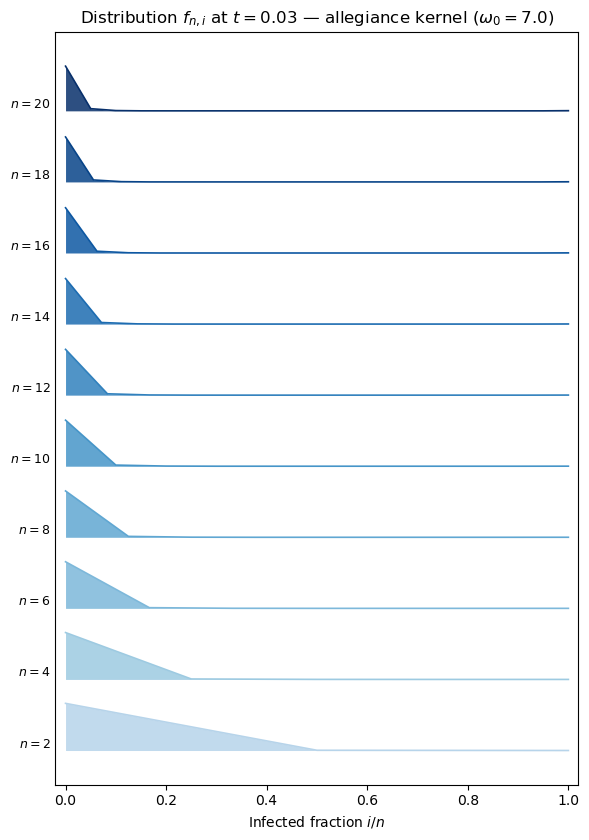

In [87]:
# Distribution of group states across n values at a single time snapshot
# Ridgeline style matching example_dist.png
I0 = 1e-3
traj_points = 5000
t_max = 20.0
scale = 7.0
print(f"Running trajectory integration with allegiance kernel (scale={scale})...")
t_all, I_all, fni_traj = integrate_I_traj_kernel(
    lam=lam_kernel,
    w_func=w_diversity_intolerance,
    w_args=(scale,),
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    nu=nu,
    I0=I0,
    traj_points=traj_points,
    t_max=t_max,
)

# Pick a snapshot — change index to explore different moments in the transient
log_snaps = np.logspace(np.log10(t_all[1]), np.log10(t_all[-1]), 5)
snap_indices = [np.argmin(np.abs(t_all - ts)) for ts in log_snaps]
tidx = snap_indices[1]   # middle snapshot is 2; try [1] or [3]
t_snap = t_all[tidx]

# n values to display — every other size from 2 to nmax
n_show = list(range(2, nmax + 1, max(1, nmax // 8)))
if nmax not in n_show:
    n_show.append(nmax)
n_show = sorted(n_show)

spacing = 1.5
cmap = plt.get_cmap("Blues")
colors = [cmap(0.3 + 0.7 * k / max(len(n_show) - 1, 1)) for k in range(len(n_show))]

fig, ax = plt.subplots(figsize=(6, len(n_show) * 0.7 + 1.5))

for k, n0 in enumerate(n_show):
    phi_vals = np.arange(n0 + 1) / n0
    dist = fni_traj[tidx, n0, :n0 + 1].copy()
    total = dist.sum()
    if total > 1e-14:
        dist /= total
    baseline = k * spacing
    ax.fill_between(phi_vals, baseline, baseline + dist,
                    alpha=0.85, color=colors[k], linewidth=0)
    ax.plot(phi_vals, baseline + dist, color=colors[k], lw=1.2)
    ax.text(-0.03, baseline, rf"$n={n0}$", ha="right", va="bottom", fontsize=9)

ax.set_xlabel(r"Infected fraction $i/n$")
ax.set_yticks([])
ax.set_xlim(-0.02, 1.02)
ax.set_title(rf"Distribution $f_{{n,i}}$ at $t={t_snap:.2f}$ — allegiance kernel ($\omega_0={scale}$)")
plt.tight_layout()
plt.savefig("./figures/group_state_ridgeline.png", dpi=300)
plt.show()